# Hoja de trabajo 2: Transformers y mecanismos de atención

**Curso:** CC3092 Deep Learning y Sistemas Inteligentes  
**Objetivo:** comprender la transición desde modelos recurrentes hacia Transformers y analizar de forma empírica los patrones de atención de BERT y GPT-2.

Este notebook integra investigación, derivaciones, implementación, visualizaciones, resultados, discusión y referencias. Las afirmaciones se redactan con palabras propias a partir de artículos originales y documentación oficial.

## 1. Configuración reproducible

La semilla fija permite repetir los ejemplos numéricos. Los modelos se cargan con atención explícita para obtener los pesos por capa y cabeza. Las figuras se guardan en la carpeta `figuras`.

In [1]:
from pathlib import Path
from time import perf_counter
import math
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid", context="notebook")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cuda


## 2. De las RNN a la atención

### El cuello de botella de seq2seq

Un encoder recurrente clásico comprime toda la oración fuente en un único estado final. Ese vector fijo debe conservar identidad, orden y relaciones entre todos los tokens. Cuando la secuencia crece, la información temprana atraviesa muchos pasos recurrentes y compite por una capacidad limitada. Esto dificulta preservar detalles y propagar gradientes.

La atención de Bahdanau conserva todos los estados del encoder. En cada paso, el decoder calcula una puntuación de alineamiento entre su estado y cada estado fuente. Una softmax convierte esas puntuaciones en pesos y produce un contexto ponderado. El decoder obtiene así un acceso directo y diferenciable a la parte pertinente de la entrada.

### Atención aditiva y multiplicativa

La atención aditiva concatena o combina consulta y clave mediante proyecciones aprendidas, una no linealidad tanh y un vector de puntuación. La atención multiplicativa calcula un producto punto, a veces después de una proyección. La variante aditiva puede ser flexible con dimensiones pequeñas. La variante de producto punto aprovecha multiplicaciones matriciales densas y suele ser más rápida en GPU y TPU por su alto nivel de paralelismo.

### Consulta, llave y valor

La analogía útil es un diccionario suave. La consulta expresa qué información se busca. Cada llave describe cuándo resulta pertinente una entrada. La similitud entre consulta y llaves produce pesos continuos. La suma ponderada de los valores recupera una mezcla de información en vez de elegir una sola entrada.

En self-attention, Q, K y V son proyecciones lineales de la misma secuencia. En cross-attention, Q procede del estado del decoder, mientras K y V proceden de la salida del encoder.

### Limitaciones recurrentes que evita el Transformer

Una RNN procesa tokens en orden y no puede paralelizar todos los pasos durante entrenamiento. Además, la ruta entre tokens distantes crece con la longitud y agrava la pérdida o explosión de gradientes. En self-attention, cada token se conecta directamente con todos los demás en una sola capa. Esto permite paralelismo por posición y rutas cortas para dependencias largas. El costo es una matriz de atención cuadrática en la longitud.

## 3. Arquitectura Transformer

### Producto punto escalado

La atención se define como

$$\operatorname{softmax}\left[\frac{QK^T}{\sqrt{d_k}}\right]V$$

Si los componentes de q y k son independientes, con media cero y varianza uno, cada producto tiene varianza uno. La suma de $d_k$ productos tiene varianza $d_k$. Dividir por $\sqrt{d_k}$ devuelve la varianza a una escala cercana a uno. Sin ese factor, los logits crecen con la dimensión, la softmax se satura y sus gradientes se aproximan a cero.

### Múltiples cabezas

Cada cabeza aprende proyecciones distintas y puede representar relaciones complementarias, como cercanía, puntuación, concordancia o referencia. Con $h$ cabezas de dimensión $d_{model}/h$, el costo dominante de las proyecciones se mantiene aproximadamente igual al de una sola cabeza de dimensión completa. La arquitectura estándar conserva cerca de $4d_{model}^2$ parámetros entre Q, K, V y la proyección de salida.

### Información posicional

Sin información adicional, self-attention es equivariante ante permutaciones. Reordenar tokens reordena las salidas pero no aporta una noción propia de antes y después.

La codificación sinusoidal asigna senos y cosenos de distintas frecuencias a cada posición. No agrega parámetros y permite extrapolar de forma limitada a longitudes nuevas. Los embeddings aprendidos pueden adaptarse al corpus, pero quedan ligados al máximo entrenado. RoPE rota pares de componentes de Q y K según su posición y hace que el producto punto dependa de desplazamientos relativos.

### Bloque completo

La conexión residual preserva una ruta directa para información y gradientes. LayerNorm estabiliza escalas entre características. La red feed-forward aplica dos transformaciones lineales y una no lineal a cada posición de forma independiente.

Post-LN normaliza después de sumar el residual, como en el artículo original. Pre-LN normaliza antes de cada subcapa y deja una ruta residual más limpia. Pre-LN suele optimizarse con mayor estabilidad en redes profundas, aunque Post-LN puede alcanzar representaciones finales distintas con una calibración cuidadosa.

### Complejidad y alternativas

La atención estándar requiere tiempo y memoria de orden $n^2$ para formar y usar la matriz entre posiciones.

- FlashAttention calcula atención exacta por bloques y reduce movimientos entre memorias. No sacrifica exactitud matemática, pero exige núcleos y hardware compatibles.
- La atención por ventanas restringe cada token a vecinos. Su costo pasa a ser cercano a lineal para ventana fija, a cambio de perder conexiones globales directas salvo que se añadan tokens globales.
- La atención lineal usa mapas de características y cambia el orden de los productos. Reduce el costo respecto a la longitud, pero aproxima o sustituye la softmax y puede alterar calidad y estabilidad.

## 4. Atención en PyTorch y Hugging Face

### PyTorch

`F.scaled_dot_product_attention` ejecuta el producto punto escalado. `attn_mask` restringe pares entre consultas y claves. `dropout_p` controla regularización y debe ser cero durante evaluación. `is_causal` crea una restricción autoregresiva. `scale` permite sustituir el factor de escala predeterminado.

`nn.MultiheadAttention` implementa proyecciones para varias cabezas. `embed_dim` fija la dimensión del modelo, `num_heads` la cantidad de cabezas, `batch_first` permite el orden lote, secuencia y características, y `kdim` junto con `vdim` permiten claves y valores con dimensiones distintas. En la llamada, `key_padding_mask` oculta padding, `attn_mask` define restricciones entre posiciones, `need_weights` solicita pesos y `average_attn_weights` decide si se promedian las cabezas.

`nn.TransformerEncoderLayer` reúne self-attention, feed-forward, residuales, normalización y dropout. Sus parámetros principales son `d_model`, `nhead`, `dim_feedforward`, `dropout` y `norm_first`. El último selecciona Pre-LN cuando es verdadero. `nn.Transformer.generate_square_subsequent_mask` produce la máscara causal triangular para impedir acceso al futuro.

### Hugging Face

`output_attentions=True` solicita los pesos posteriores a la softmax. El resultado contiene una tupla con un tensor por capa. Para self-attention, cada tensor presenta ejes de lote, cabezas, consultas y claves. Con una secuencia de longitud $n$, la forma es lote por cabezas por $n$ por $n$.

## 5. Verificación manual y práctica básica

Para una consulta, se calculan productos con cada llave, se escalan, se normalizan con softmax y se combinan los valores. La siguiente celda muestra cada resultado y lo compara con la función optimizada de PyTorch.

In [2]:
Q = torch.tensor([[[[1.0, 0.0]]]])
K = torch.tensor([[[[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]]]])
V = torch.tensor([[[[1.0, 0.0], [0.0, 2.0], [3.0, 1.0]]]])

scores = Q @ K.transpose(-2, -1) / math.sqrt(K.size(-1))
weights = scores.softmax(dim=-1)
manual = weights @ V
pytorch = F.scaled_dot_product_attention(Q, K, V, dropout_p=0.0)

print("Puntuaciones:", scores)
print("Pesos:", weights)
print("Salida manual:", manual)
print("Salida PyTorch:", pytorch)
torch.testing.assert_close(manual, pytorch)

Puntuaciones: tensor([[[[0.7071, 0.0000, 0.7071]]]])
Pesos: tensor([[[[0.4011, 0.1978, 0.4011]]]])
Salida manual: tensor([[[[1.6044, 0.7967]]]])
Salida PyTorch: tensor([[[[1.6044, 0.7967]]]])


In [3]:
embed_dim = 8
heads = 2
x = torch.randn(2, 5, embed_dim)
mha = nn.MultiheadAttention(embed_dim, heads, batch_first=True)
out, attn = mha(x, x, x, need_weights=True, average_attn_weights=False)
layer = nn.TransformerEncoderLayer(
    d_model=embed_dim,
    nhead=heads,
    dim_feedforward=32,
    dropout=0.0,
    batch_first=True,
    norm_first=True,
)
causal_mask = nn.Transformer.generate_square_subsequent_mask(x.size(1))
encoded = layer(x, src_mask=causal_mask)
print("Salida MHA:", tuple(out.shape))
print("Pesos por cabeza:", tuple(attn.shape))
print("Salida del encoder:", tuple(encoded.shape))
print(causal_mask)

Salida MHA: (2, 5, 8)
Pesos por cabeza: (2, 2, 5, 5)
Salida del encoder: (2, 5, 8)
tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])


### Escalamiento teórico y costo medido

El número de elementos de la matriz crece como $n^2$. La medición siguiente usa tensores pequeños y repeticiones breves para observar la tendencia sin convertirla en una prueba exhaustiva de rendimiento.

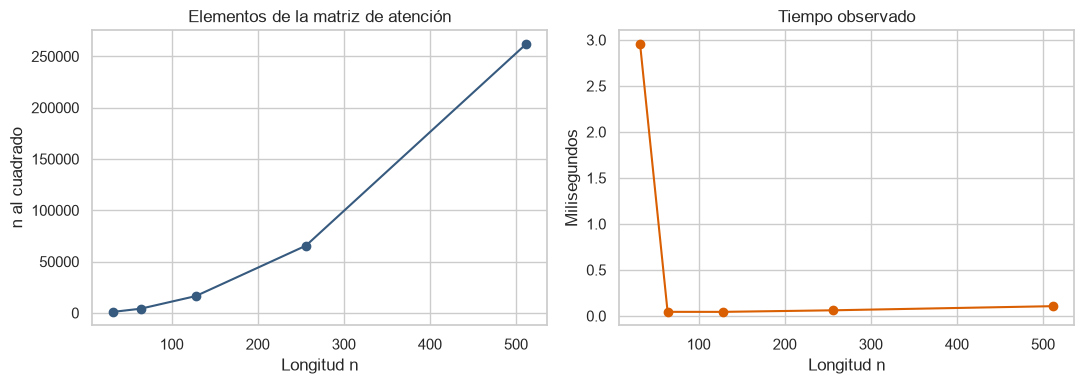

In [4]:
lengths = np.array([32, 64, 128, 256, 512])
theoretical = lengths ** 2
times = []
for n in lengths:
    q = torch.randn(1, 2, int(n), 32, device=DEVICE)
    k = torch.randn_like(q)
    v = torch.randn_like(q)
    start = perf_counter()
    for _ in range(3):
        _ = F.scaled_dot_product_attention(q, k, v, dropout_p=0.0)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    times.append((perf_counter() - start) / 3 * 1000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(lengths, theoretical, marker="o", color="#375a7f")
axes[0].set_title("Elementos de la matriz de atención")
axes[0].set_xlabel("Longitud n")
axes[0].set_ylabel("n al cuadrado")
axes[1].plot(lengths, times, marker="o", color="#d95f02")
axes[1].set_title("Tiempo observado")
axes[1].set_xlabel("Longitud n")
axes[1].set_ylabel("Milisegundos")
fig.tight_layout()
fig.savefig(FIG_DIR / "escalamiento_atencion.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Atención en BERT y GPT-2

BERT usa atención bidireccional. GPT-2 usa atención causal y solo permite atender a la posición actual y al pasado. Se emplea la misma oración principal para facilitar la comparación.

In [5]:
os.environ["HF_HUB_DISABLE_XET"] = "1"
from transformers import AutoModel, AutoTokenizer

sentence = "The curious student carefully reads the book."
tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True,
    attn_implementation="eager",
).to(DEVICE).eval()

tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained(
    "gpt2",
    output_attentions=True,
    attn_implementation="eager",
).to(DEVICE).eval()

def run_model(model, tokenizer, text):
    batch = tokenizer(text, return_tensors="pt")
    batch = {key: value.to(DEVICE) for key, value in batch.items()}
    with torch.no_grad():
        output = model(**batch, output_attentions=True)
    tokens = tokenizer.convert_ids_to_tokens(batch["input_ids"][0])
    attentions = [item.detach().cpu() for item in output.attentions]
    return tokens, attentions

bert_tokens, bert_attn = run_model(bert, tok_bert, sentence)
gpt_tokens, gpt_attn = run_model(gpt2, tok_gpt2, sentence)
print("BERT:", len(bert_attn), bert_attn[0].shape, bert_tokens)
print("GPT-2:", len(gpt_attn), gpt_attn[0].shape, gpt_tokens)

BERT: 12 torch.Size([1, 12, 10, 10]) ['[CLS]', 'the', 'curious', 'student', 'carefully', 'reads', 'the', 'book', '.', '[SEP]']
GPT-2: 12 torch.Size([1, 12, 8, 8]) ['The', 'Ġcurious', 'Ġstudent', 'Ġcarefully', 'Ġreads', 'Ġthe', 'Ġbook', '.']


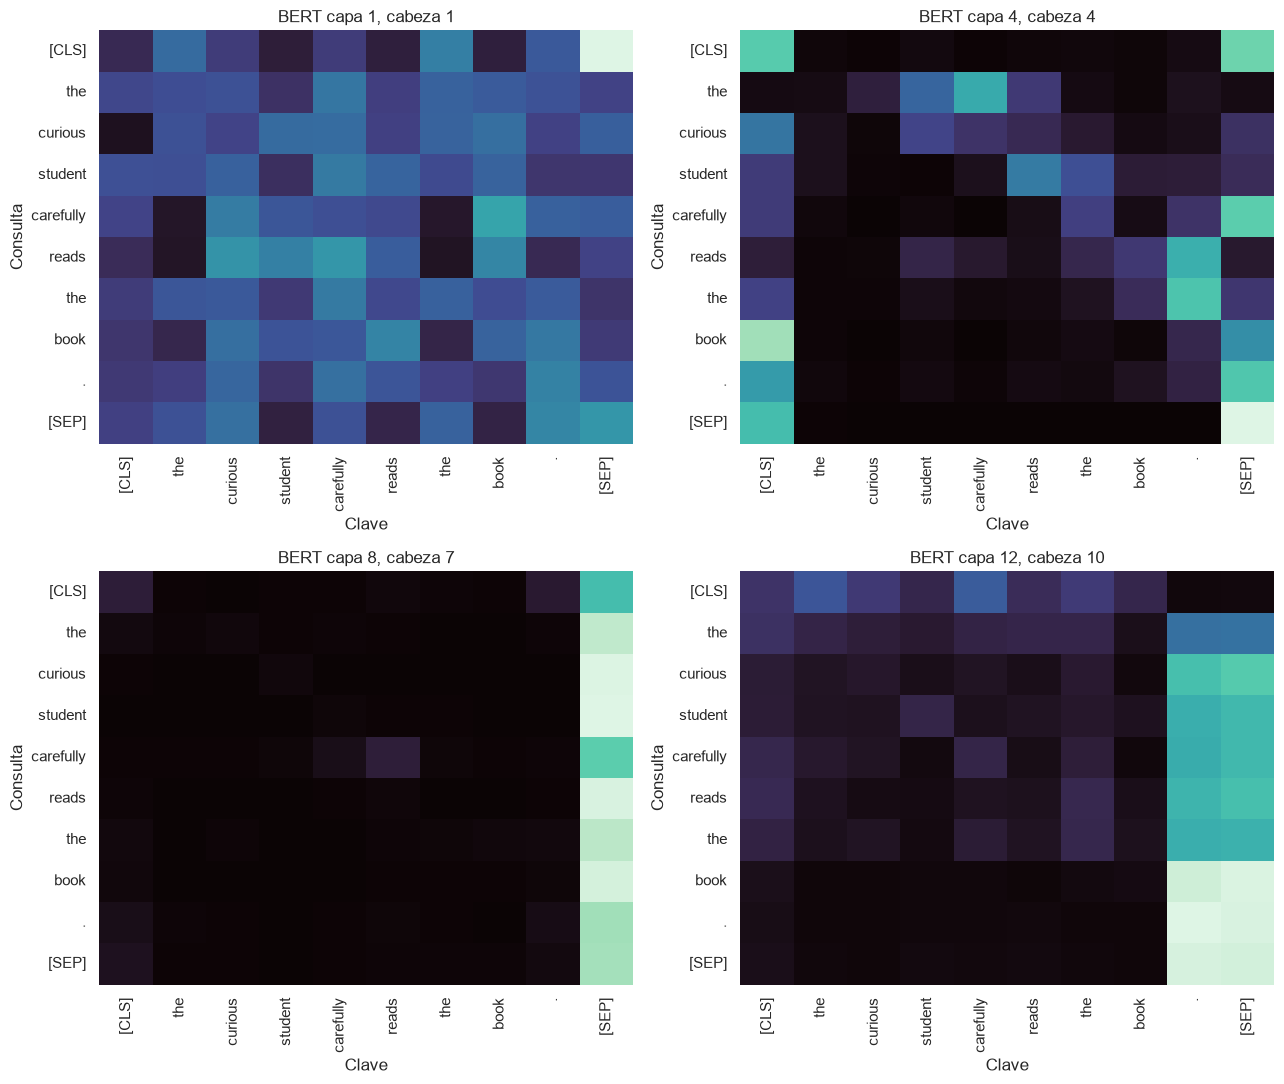

In [6]:
def heatmap(ax, matrix, tokens, title):
    sns.heatmap(
        matrix,
        ax=ax,
        cmap="mako",
        vmin=0,
        vmax=max(0.01, float(matrix.max())),
        xticklabels=tokens,
        yticklabels=tokens,
        cbar=False,
    )
    ax.set_title(title)
    ax.set_xlabel("Clave")
    ax.set_ylabel("Consulta")

selections = [(0, 0), (3, 3), (7, 6), (11, 9)]
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (layer_idx, head_idx) in zip(axes.flat, selections):
    matrix = bert_attn[layer_idx][0, head_idx].numpy()
    heatmap(ax, matrix, bert_tokens, f"BERT capa {layer_idx + 1}, cabeza {head_idx + 1}")
fig.tight_layout()
fig.savefig(FIG_DIR / "cabezas_bert.png", dpi=180, bbox_inches="tight")
plt.show()

Los mapas permiten buscar diagonales asociadas con identidad, bandas cercanas asociadas con contexto local y columnas intensas hacia tokens especiales o puntuación. Las diferencias entre cabezas apoyan la idea de especialización, aunque una imagen aislada no demuestra función causal.

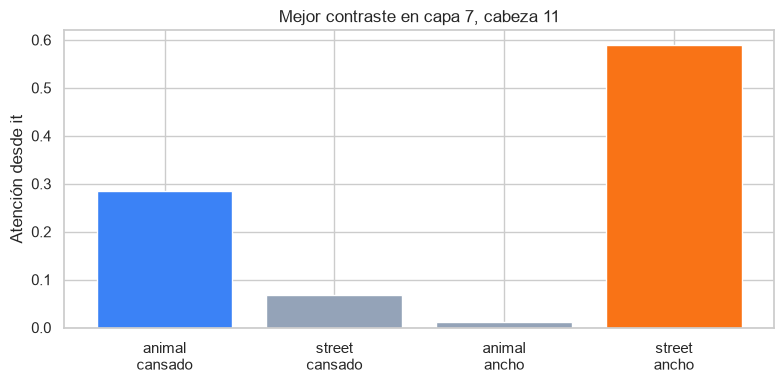

{'capa': 7, 'cabeza': 11, 'contraste': 0.7954158997163177, 'valores': [0.2842691242694855, 0.06708639860153198, 0.011940130032598972, 0.5901733040809631]}


In [7]:
text_tired = "The animal didn't cross the street because it was too tired."
text_wide = "The animal didn't cross the street because it was too wide."
tired_tokens, tired_attn = run_model(bert, tok_bert, text_tired)
wide_tokens, wide_attn = run_model(bert, tok_bert, text_wide)

def token_index(tokens, target):
    return tokens.index(target)

idx_it = token_index(tired_tokens, "it")
idx_animal = token_index(tired_tokens, "animal")
idx_street = token_index(tired_tokens, "street")

best = None
for layer_idx in range(len(tired_attn)):
    for head_idx in range(tired_attn[layer_idx].shape[1]):
        tired_animal = float(tired_attn[layer_idx][0, head_idx, idx_it, idx_animal])
        tired_street = float(tired_attn[layer_idx][0, head_idx, idx_it, idx_street])
        wide_animal = float(wide_attn[layer_idx][0, head_idx, idx_it, idx_animal])
        wide_street = float(wide_attn[layer_idx][0, head_idx, idx_it, idx_street])
        contrast = tired_animal - tired_street + wide_street - wide_animal
        row = (contrast, layer_idx, head_idx, tired_animal, tired_street, wide_animal, wide_street)
        if best is None or row[0] > best[0]:
            best = row

contrast, layer_idx, head_idx, ta, ts, wa, ws = best
labels = ["animal\ncansado", "street\ncansado", "animal\nancho", "street\nancho"]
values = [ta, ts, wa, ws]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, values, color=["#3b82f6", "#94a3b8", "#94a3b8", "#f97316"])
ax.set_ylabel("Atención desde it")
ax.set_title(f"Mejor contraste en capa {layer_idx + 1}, cabeza {head_idx + 1}")
fig.tight_layout()
fig.savefig(FIG_DIR / "correferencia_bert.png", dpi=180, bbox_inches="tight")
plt.show()
print({"capa": layer_idx + 1, "cabeza": head_idx + 1, "contraste": contrast, "valores": values})

La búsqueda recorre todas las cabezas y elige la que maximiza el cambio esperado. El contraste es positivo cuando la atención desde `it` favorece más a `animal` en la oración con `tired` y más a `street` en la oración con `wide`. Esto constituye evidencia descriptiva de sensibilidad contextual, no una prueba de que esa cabeza resuelva por sí sola la referencia.

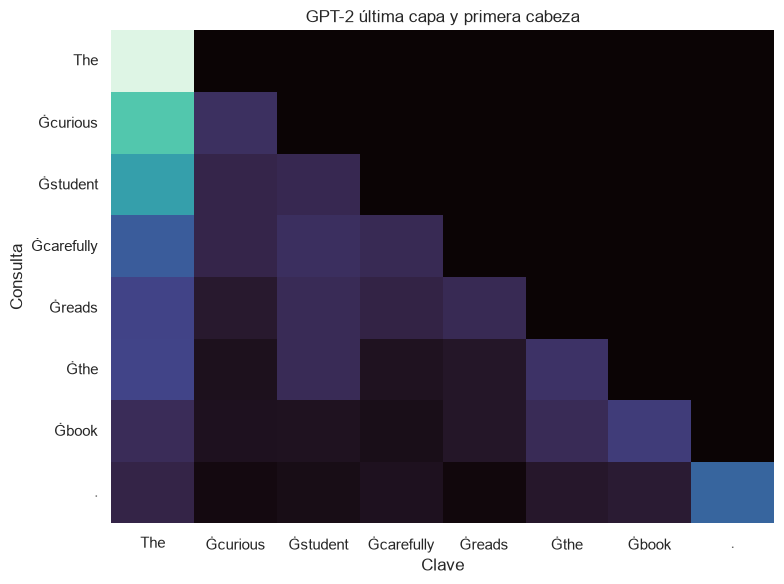

Máximo sobre la diagonal: 0.00000000


In [8]:
layer_for_mask = len(gpt_attn) - 1
matrix = gpt_attn[layer_for_mask][0, 0].numpy()
upper_max = float(np.triu(matrix, k=1).max())
fig, ax = plt.subplots(figsize=(8, 6))
heatmap(ax, matrix, gpt_tokens, "GPT-2 última capa y primera cabeza")
fig.tight_layout()
fig.savefig(FIG_DIR / "causalidad_gpt2.png", dpi=180, bbox_inches="tight")
plt.show()
print(f"Máximo sobre la diagonal: {upper_max:.8f}")
assert upper_max < 1e-6

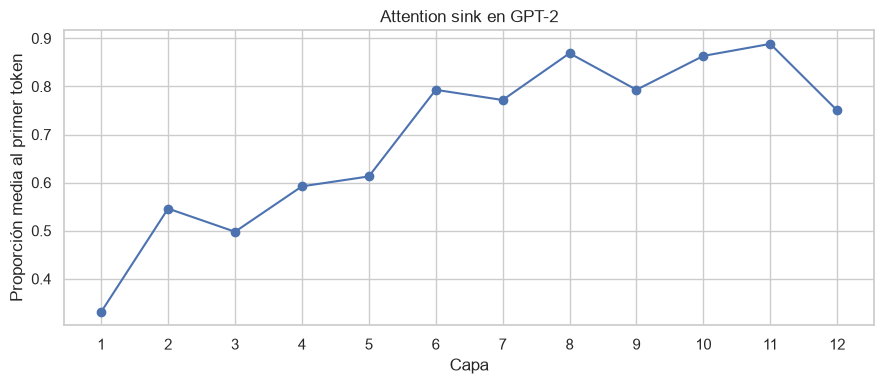

[0.3312 0.546  0.4978 0.5922 0.6129 0.793  0.7718 0.869  0.793  0.8635
 0.8885 0.75  ]


In [9]:
first_token_share = []
for layer in gpt_attn:
    first_token_share.append(float(layer[0, :, 1:, 0].mean()))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(first_token_share) + 1), first_token_share, marker="o")
ax.set_xlabel("Capa")
ax.set_ylabel("Proporción media al primer token")
ax.set_title("Attention sink en GPT-2")
ax.set_xticks(np.arange(1, len(first_token_share) + 1))
fig.tight_layout()
fig.savefig(FIG_DIR / "attention_sink_gpt2.png", dpi=180, bbox_inches="tight")
plt.show()
print(np.round(first_token_share, 4))

Un attention sink es una posición que acumula masa de atención aunque su contenido no sea decisivo. Los primeros tokens pueden funcionar como destino estable para masa no utilizada. StreamingLLM mostró que conservar algunos tokens iniciales junto con una ventana reciente ayuda a mantener la generación durante secuencias largas.

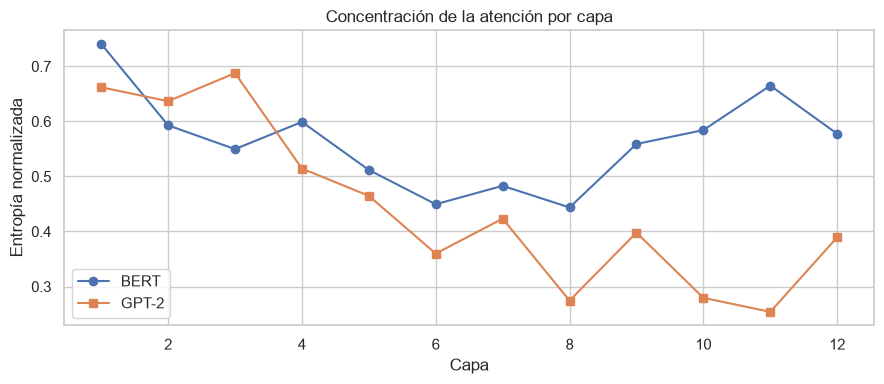

BERT: [0.741 0.593 0.55  0.599 0.512 0.449 0.483 0.444 0.559 0.584 0.665 0.577]
GPT-2: [0.662 0.637 0.688 0.514 0.465 0.36  0.423 0.274 0.398 0.279 0.254 0.389]


In [10]:
def normalized_entropy_bidirectional(layers):
    result = []
    for layer in layers:
        probs = layer.clamp_min(1e-12)
        entropy = -(probs * probs.log()).sum(dim=-1)
        result.append(float((entropy / math.log(probs.size(-1))).mean()))
    return result

def normalized_entropy_causal(layers):
    result = []
    for layer in layers:
        probs = layer[0]
        values = []
        for query in range(1, probs.size(-2)):
            row = probs[:, query, : query + 1].clamp_min(1e-12)
            entropy = -(row * row.log()).sum(dim=-1) / math.log(query + 1)
            values.append(entropy.mean())
        result.append(float(torch.stack(values).mean()))
    return result

bert_entropy = normalized_entropy_bidirectional(bert_attn)
gpt_entropy = normalized_entropy_causal(gpt_attn)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 13), bert_entropy, marker="o", label="BERT")
ax.plot(range(1, 13), gpt_entropy, marker="s", label="GPT-2")
ax.set_xlabel("Capa")
ax.set_ylabel("Entropía normalizada")
ax.set_title("Concentración de la atención por capa")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "entropia_por_capa.png", dpi=180, bbox_inches="tight")
plt.show()
print("BERT:", np.round(bert_entropy, 3))
print("GPT-2:", np.round(gpt_entropy, 3))

## 7. Discusión y análisis

### Escalabilidad frente a las RNN

La atención hizo viable entrenar modelos mayores porque elimina la dependencia temporal entre posiciones durante entrenamiento. Las multiplicaciones de todas las consultas y claves se ejecutan en paralelo y aprovechan aceleradores. Además, la longitud de la ruta entre dos tokens es constante dentro de una capa de atención, mientras en una RNN crece con su separación. La desventaja es el costo cuadrático, que domina con secuencias extensas.

### Especialización y utilidad de las cabezas

Los mapas muestran patrones diferentes entre capas y cabezas. Algunas concentran peso en la diagonal, otras en vecinos, puntuación o tokens especiales. La prueba de correferencia busca una cabeza sensible al cambio semántico entre `tired` y `wide`. Esa diversidad es evidencia de especialización. Sin embargo, cabezas difusas o repetitivas pueden ser redundantes y estudios de poda muestran que no todas contribuyen por igual.

### Atención como explicación

Los pesos indican por dónde fluye información en una operación concreta, pero no miden por sí solos la influencia causal sobre la predicción final. Jain y Wallace encontraron baja correlación con medidas basadas en gradientes y distribuciones alternativas con resultados similares. Wiegreffe y Pinter señalaron que la conclusión depende de la definición de explicación y propusieron pruebas más controladas.

Las visualizaciones de este notebook son útiles para formular hipótesis, como una preferencia contextual de `it`, pero no bastan para afirmar causalidad. Una explicación más sólida combinaría ablación de cabezas, intervención sobre pesos, gradientes y comparación entre semillas.

### Cuándo preferir RNN o CNN

Una RNN sigue siendo razonable para flujos estrictamente en línea con memoria limitada y latencia constante por paso. Una CNN puede ser preferible cuando predominan patrones locales, se necesita una inductiva fuerte de localidad o el hardware favorece convoluciones. También pueden resultar más económicas en dispositivos pequeños y conjuntos de datos modestos.

### Documentos de cien mil tokens

La matriz estándar tendría diez mil millones de pares por cabeza. Su memoria y cómputo serían prohibitivos. Consideraría ventanas deslizantes con tokens globales, atención dispersa, modelos lineales, procesamiento jerárquico y recuperación de fragmentos pertinentes. FlashAttention reduce memoria intermedia y movimientos de datos, pero no elimina el número cuadrático de operaciones.

## 8. Conclusiones

La atención sustituye el resumen fijo y la ruta secuencial de las RNN por acceso directo y ponderado a toda la secuencia. El escalamiento por raíz de la dimensión mantiene una softmax entrenable, mientras las múltiples cabezas ofrecen subespacios complementarios. Las pruebas distinguen claramente la atención bidireccional de BERT y la máscara causal de GPT-2. También muestran que una cabeza puede responder a cambios semánticos y que el primer token puede absorber atención.

Los pesos de atención son herramientas de inspección valiosas, pero deben interpretarse junto con intervenciones causales. Para contextos extremos, la atención exacta completa requiere técnicas que mejoren el uso de memoria o reduzcan el conjunto de pares atendidos.

## 9. Referencias

1. Hugging Face. Sin fecha. ¿Cómo funcionan los Transformers? Curso de Hugging Face, edición en español. https://huggingface.co/docs/course/es/chapter1/4
2. Hugging Face. Sin fecha. Mecanismos de atención. Documentación de Transformers, edición en español. https://huggingface.co/docs/transformers/es/attention
3. Hugging Face. Sin fecha. Glosario de Transformers. Documentación en español. https://huggingface.co/docs/transformers/es/glossary
4. IBM. Sin fecha. ¿Qué es un mecanismo de atención? IBM Think, edición en español. https://www.ibm.com/es-es/think/topics/attention-mechanism
5. IBM. Sin fecha. ¿Qué es el GPT, transformador generativo preentrenado? IBM Think, edición en español. https://www.ibm.com/es-es/think/topics/gpt